In [1]:
%env MUJOCO_GL=osmesa
import functools
import json
import math
import os
import pathlib
import sys
import time

import cv2
import numpy as np
import mediapy as media

from openpi_client.websocket_client_policy import WebsocketClientPolicy

sys.path.append('../py_script')

env: MUJOCO_GL=osmesa


In [2]:
import cv2
from threading import Thread

class CameraReader:
    def __init__(self, camera_ids):
        self.cameras = [cv2.VideoCapture(i) for i in camera_ids]
        self.obs = None
        self.running = False
        self.run_thread = None

    def start(self):
        self.running = True
        self.run_thread = Thread(target=self._spin_thread)
        self.run_thread.start()

    def stop(self):
        self.running = False

    def _spin_thread(self):
        while self.running:
            obs = []
            for camera in self.cameras:
                obs.append(camera.read())
            self.obs = obs

    def get_images(self):
        results = self.obs # Pointer copy
        return [r[1] for r in results]

cameras = CameraReader([4, 10])
cameras.start()

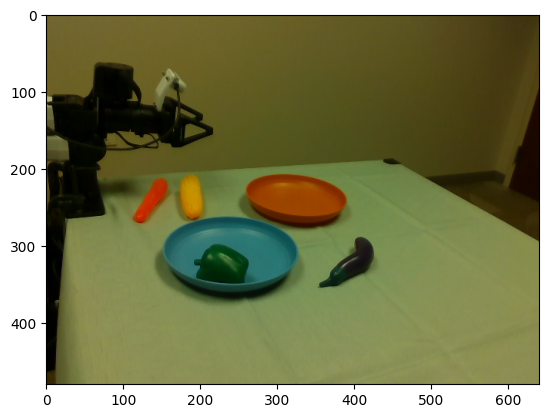

In [3]:
import matplotlib.pyplot as plt
images = cameras.get_images()
plt.imshow(images[0][:, :, ::-1])
plt.show()

In [4]:
DEFAULT_ROBOT_PORT=11333
import portal
from i2rt.robots.robot import Robot

class ClientRobot(Robot):
    """A simple client for a follower robot."""

    def __init__(self, port: int = DEFAULT_ROBOT_PORT, host: str = "127.0.0.1"):
        self._client = portal.Client(f"{host}:{port}")

    def get_joint_pos(self) -> np.ndarray:
        """Get the current state of the follower obot.

        Returns:
            T: The current state of the follower robot.
        """
        return self._client.get_joint_pos().result()

    def command_joint_pos(self, joint_pos: np.ndarray) -> None:
        """Command the leader robot to the given state.

        Args:
            joint_pos (T): The state to command the follower robot to.
        """
        self._client.command_joint_pos(joint_pos)

    def get_observations():
        pass
    def num_dofs():
        pass

robot = ClientRobot()

[Client] Connecting to 127.0.0.1:11333
[Client] Connection established


In [89]:
def make_obs():
    images = cameras.get_images()
    return {
        "image": images[0][:, :, ::-1],
        "wrist_image": images[1][:, :, ::-1],
        "state": robot.get_joint_pos()
    }

policy = WebsocketClientPolicy(port=9898)

In [91]:
task = "put the green bell pepper on the blue plate"
# task = "pick up the orange plate"
policy.initialize(None, task)

t0 = time.monotonic()
vla_output = policy.infer(make_obs())
t1 = time.monotonic()
print(t1 - t0, "elapsed")
actions = vla_output['actions']
print(actions)

1.8639899639965734 elapsed
[[-5.37872053e-04 -1.92316556e-02  1.26806444e-02  7.01978153e-03
   8.50516372e-04  4.10596911e-03  1.33806502e+00]
 [-2.17955776e-04 -1.87848515e-02  1.27887976e-02  6.63330176e-03
   1.30371614e-03  3.95635796e-03  1.32961943e+00]
 [-1.01147775e-05 -1.95692120e-02  1.30402190e-02  6.63524613e-03
   1.38078541e-03  5.05852736e-03  1.34144088e+00]
 [-1.03150654e-04 -1.99655351e-02  1.29634753e-02  6.49046578e-03
   1.78034651e-03  5.26576121e-03  1.34163906e+00]
 [ 7.67031206e-05 -2.02439269e-02  1.22334520e-02  6.28284150e-03
   1.73147716e-03  4.82165663e-03  1.31647492e+00]
 [ 2.35109924e-04 -1.95742360e-02  1.22243306e-02  5.94090654e-03
   1.50295162e-03  4.92662903e-03  1.32299869e+00]
 [-1.33375104e-05 -2.12659050e-02  1.26861816e-02  6.52429382e-03
   1.93031102e-03  5.30196140e-03  1.33926268e+00]
 [-2.96672609e-04 -2.04336145e-02  1.18845272e-02  6.19844700e-03
   1.54447694e-03  4.69381452e-03  1.33507771e+00]
 [ 1.32276497e-06 -2.09193951e-02  1.

In [83]:
gripper_limits = [6.355838298797607, 1.1629282236099243]
gripper_range = gripper_limits[1] - gripper_limits[0]

# video_images = []
# wrist_video_images = []
for i in range(30):
    vla_output = policy.infer(make_obs())
    actions = vla_output['actions']
    
    for action in actions:
        obs = make_obs()
        state = obs['state']
        command = state
        command[:6] += action[:6]
        command[6] = (action[6] - gripper_limits[0]) / gripper_range
        robot.command_joint_pos(command)
        video_images.append(obs['image'])
        wrist_video_images.append(obs['wrist_image'])
        time.sleep(1/30)

In [84]:
import mediapy
mediapy.write_video("bell_pepper_wrist.mp4", video_images)
mediapy.write_video("bell_pepper_long_wrist.mp4", wrist_video_images)